In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
#A simple scalar value function

def f(x):
    return 4*x**2 - 5*x + 1

In [4]:
f(3.0)

22.0

In [6]:
# x values
xs = np.arange(-10, 10, 0.5)
ys = f(xs)
ys

array([451. , 409.5, 370. , 332.5, 297. , 263.5, 232. , 202.5, 175. ,
       149.5, 126. , 104.5,  85. ,  67.5,  52. ,  38.5,  27. ,  17.5,
        10. ,   4.5,   1. ,  -0.5,   0. ,   2.5,   7. ,  13.5,  22. ,
        32.5,  45. ,  59.5,  76. ,  94.5, 115. , 137.5, 162. , 188.5,
       217. , 247.5, 280. , 314.5])

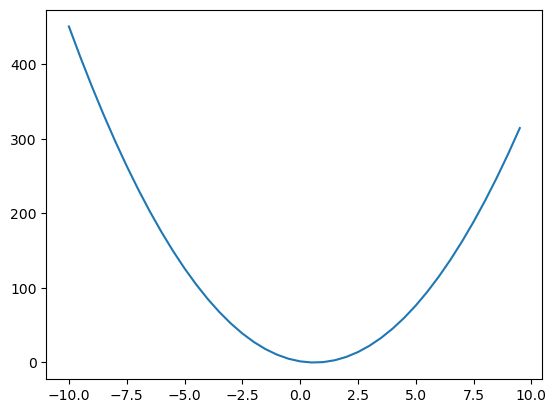

In [7]:
plt.plot(xs,ys)

In [29]:
#derivative of a simple function
h = 0.000001
x = 4
d = (f(x+h)-f(x))/h
d

27.000003996136

In [30]:
#Function with more than one parameters

def f2(a,b,c):
    return a*b+c

In [73]:
#Get more complex


a = -2
b =  5
c = 7
val1 = f2(a,b,c)
h = 0.0001

print(val1)



-3


In [74]:
# Derivative wrt a (will be b only)

val1 = f2(a,b,c)

a2 = a + h

val2 = f2(a2,b,c)


slope = (val2-val1)/h
print(val1)
print(val2)
print(slope)

-3
-2.9994999999999994
5.000000000006111


In [75]:
#Derivative wrt b (will be a only)

val1 = f2(a,b,c)

b2 = b + h

val2 = f2(a,b2,c)


slope = (val2-val1)/h
print(val1)
print(val2)
print(slope)

-3
-3.0001999999999995
-1.9999999999953388


In [76]:
# Derivative wrt c (will be 1 only)
val1 = f2(a,b,c)

c2 = c + h

val2 = f2(a,b,c2)


slope = (val2-val1)/h
print(val1)
print(val2)
print(slope)

-3
-2.9999000000000002
0.9999999999976694


In [121]:
# Now we start creating the data structure required to build neural network

class Value:
    def __init__(self, data, _children=(), _op = '', label=''):
        #initialize with a value (keeps track of its value)
        self.data = data
        self._prev = (_children) #set(_children) for efficiency. doing this so i can see inner children
        self._op = _op
        self.label = label
    # Python uses this to print (?)
    def __repr__(self):
        return f"Value(data={self.data})"
    
    
    # Adding two values
    def __add__(self, other):
        ## needs to be a value object as well.
        return Value((self.data + other.data), (self, other), "+")
    
    def __mul__(self,other):
        return Value(self.data * other.data, (self, other), '*')
    
    
    
    """
    Now, we need connective tissues of the network (Which values created which values relationships).
    changes are made to the above class definition to accomodate this. (children mean the parents that created
    the current Value, inverted tree.) we also need to store what operations happened between them.

    """
 
    
    


In [125]:
a = Value(3.0, label='a'); 
b = Value(5.0, label='b'); 
c = Value(-10.0, label='c');

e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'


In [126]:
#Visualization of these relationships of a Value object using graphviz

from graphviz import Digraph


def trace(root):
    nodes,edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    
    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={'rankdir':'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label = n._op)
            dot.edge(uid+n._op, uid)
            
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    
    return dot

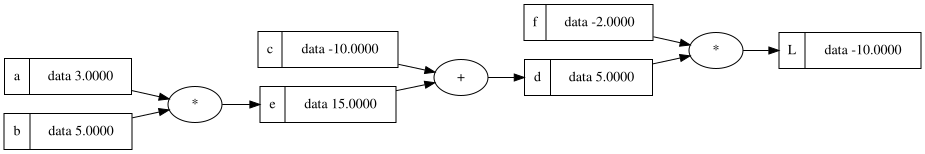

In [127]:
draw_dot(L)